In [1]:
import os
from pathlib import Path
os.chdir(Path().parent)  # Change working directory to the project root
print(f"Current working directory: {os.getcwd()}")

Current working directory: d:\Programming\vector-based-image-similarity-search


In [2]:
# check available GPUs
import torch
print(f"Using: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Using: CPU


In [3]:
import cv2
import random
import matplotlib.pyplot as plt
import cv2
import numpy as np

from src.config import *
from src.index_faces import vector_id_for, index_directory
from src.face_embedding import generate_face_embedding, _get_app, _normalize

*****
# Inspect the data

In [4]:
# check available images in the face_images directory
face_images_dir = FACE_IMAGE_DIR
def check_face_images_directory(face_images_dir):
    if not face_images_dir.exists():
        print(f"Directory {face_images_dir} does not exist.")
    else:
        image_files = list(face_images_dir.glob("*"))
        if not image_files:
            print(f"No images found in {face_images_dir}.")
        else:
            print(f"Found {len(image_files)} images in {face_images_dir}:")
            for img in image_files:
                print(f" - {img.name}")

check_face_images_directory(face_images_dir)

Found 23 images in data\face_images:
 - 000001.jpg
 - 000002.jpg
 - 000003.jpg
 - 000004.jpg
 - 000005.jpg
 - 000006.jpg
 - 000007.jpg
 - 000008.jpg
 - 000009.jpg
 - 000010.jpg
 - 000011.jpg
 - 000012.jpg
 - 000013.jpg
 - 000014.jpg
 - 000015.jpg
 - 000016.jpg
 - 000017.jpg
 - 000018.jpg
 - 000019.jpg
 - 000020.jpg
 - Katie+Kaars.jpg
 - Katie_left.jpg
 - Katie_right.jpg


In [5]:
check_face_images_directory(Path('data/query_images'))

Found 6 images in data\query_images:
 - 000016-Half.jpg
 - 000016.jpg
 - 000030.jpg
 - Katie+Kaars.jpg
 - Katie_left.jpg
 - Katie_right.jpg


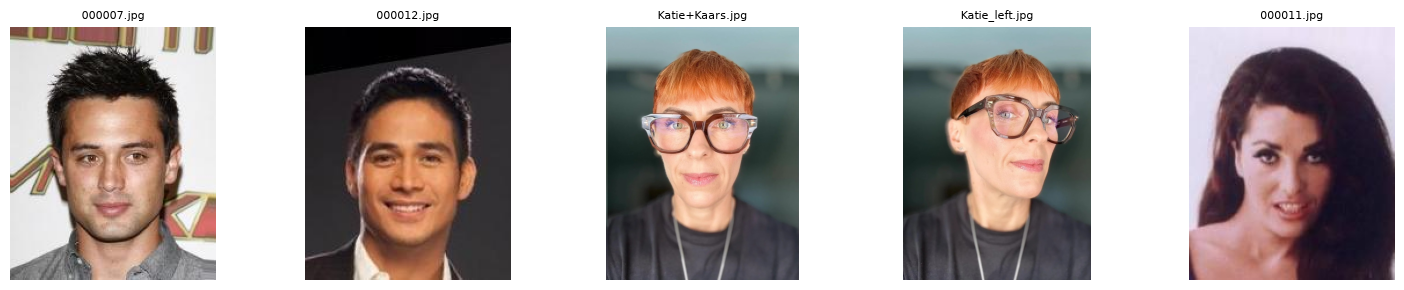

In [6]:
def display_random_images(face_images_dir, num_images=5):
    """Display random images in a single row."""
    image_files = list(face_images_dir.glob("*"))

    if len(image_files) < num_images:
        print(f"Not enough images to display. Found {len(image_files)} images.")
        return

    random_images = random.sample(image_files, num_images)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))

    for ax, img_path in zip(axes, random_images):
        img = cv2.imread(str(img_path))

        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
            ax.set_title(img_path.name, fontsize=8)
            ax.axis("off")
        else:
            ax.set_title("Failed to load")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

display_random_images(face_images_dir)

*****
# Test with one single image

In [7]:
sample_image_path = Path(list(face_images_dir.glob("*"))[random.randint(0,20)])  # Get the first image in the directory
print(f"Sample image for testing: {sample_image_path}")

Sample image for testing: data\face_images\Katie+Kaars.jpg


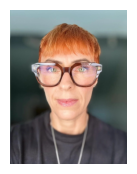

In [8]:
img = cv2.imread(str(sample_image_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display image
fig, ax = plt.subplots(figsize=(2, 2))
ax.imshow(img_rgb)
ax.axis("off")

plt.show()

In [9]:
vector_id_for(sample_image_path)  # Test the vector_id_for function

'face::Katie+Kaars'

In [10]:
angle, emd = generate_face_embedding(sample_image_path)
print(f"Angle: {angle}")
print(f"Generated embedding for {sample_image_path.name}: {emd[:5]}... (length: {len(emd)})")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\sajan/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\sajan/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\sajan/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\sajan/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\sajan/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.

d:\Programming\vector-based-image-similarity-search\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


In [11]:
# Fixed ArcFace 112x112 landmark reference template
# It is the standard target position used for ArcFace alignment.
ARC_FACE_TEMPLATE = np.array([
    [38.2946, 51.6963],  # left eye
    [73.5318, 51.5014],  # right eye
    [56.0252, 71.7366],  # nose
    [41.5493, 92.3655],  # left mouth
    [70.7299, 92.2041],  # right mouth
], dtype=np.float32)

In [12]:
def visualize_face_pipeline(path: Path):
    """
    Visualize the InsightFace pipeline:

        Original
            ↓
        Face Detection + Landmarks
            ↓
        Face Alignment
            ↓
        Recognition Input
    """
    # Read image
    image = cv2.imread(str(path))

    if image is None:
        raise ValueError(f"Could not decode image: {path}")

    original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # InsightFace detection
    # InsightFace automatically detects:
    # - face bounding box
    # - 5 facial landmarks
    # - face embedding
    faces = _get_app().get(image)

    if len(faces) == 0:
        raise ValueError(f"No face detected: {path}")

    # Select largest face
    if len(faces) > 1:
        faces.sort(
            key=lambda f: (
                (f.bbox[2] - f.bbox[0]) *
                (f.bbox[3] - f.bbox[1])
            ),
            reverse=True,
        )
        print(f"Warning: {path} contains {len(faces)} faces. Using the largest face.")

    face = faces[0]

    # Get automatically detected landmarks
    # These coordinates come directly from InsightFace.
    detected_landmarks = np.asarray(face.kps, dtype=np.float32)

    print("\nDetected landmarks:\n", detected_landmarks)

    # Visualize detection 
    detection_image = image.copy()
    x1, y1, x2, y2 = face.bbox.astype(int)

    # Face bounding box
    cv2.rectangle(
        detection_image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        3,
    )

    # Automatically detected landmarks
    for point in detected_landmarks:
        x, y = point.astype(int)
        cv2.circle(
            detection_image,
            (x, y),
            5,
            (0, 0, 255),
            -1,
        )
    detection_rgb = cv2.cvtColor(detection_image, cv2.COLOR_BGR2RGB)

 
    # Perform alignment for visualization
    # InsightFace internally performs the equivalent landmark-based alignment for recognition.
    # Here we reproduce that transformation only so we can visualize the aligned face.
 
    transform_matrix, _ = cv2.estimateAffinePartial2D(
        detected_landmarks,
        ARC_FACE_TEMPLATE,
        method=cv2.LMEDS,
    )

    if transform_matrix is None:
        raise ValueError("Could not calculate face alignment transform.")

    aligned_face = cv2.warpAffine(
        image,
        transform_matrix,
        (112, 112),
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0),
    )

    aligned_rgb = cv2.cvtColor(aligned_face, cv2.COLOR_BGR2RGB)

 
    # Recognition input
    # This is the standardized face representation that is fed into the ArcFace recognition model. 
    recognition_input = aligned_face.copy()
    recognition_rgb = cv2.cvtColor(recognition_input, cv2.COLOR_BGR2RGB)
 
    # actual InsightFace embedding
    embedding = _normalize(face.embedding)


    # Display all four stages 
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Original
    axes[0].imshow(original_rgb)
    axes[0].set_title("Original Image", fontsize=13)
    axes[0].axis("off")

    # Detection
    axes[1].imshow(detection_rgb)
    axes[1].set_title("Face Detection + Landmarks", fontsize=13)
    axes[1].axis("off")

    # Alignment
    axes[2].imshow(aligned_rgb)
    axes[2].set_title("Aligned Face (112×112)", fontsize=13)
    axes[2].axis("off")

    # Recognition input
    axes[3].imshow(recognition_rgb)
    axes[3].set_title("Recognition Input", fontsize=13)
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

 
    # Print embedding information
    print("\nEmbedding information:")
    print("Dimension :", embedding.shape)
    print("Dtype     :", embedding.dtype)
    print("Norm      :", np.linalg.norm(embedding))
    print(f"Embedding: {emd[:5]}... {emd[-5:]}")


Detected landmarks:
 [[304.15198 416.97958]
 [505.36386 418.8974 ]
 [395.14255 548.34595]
 [319.84103 628.15497]
 [488.31128 629.6063 ]]


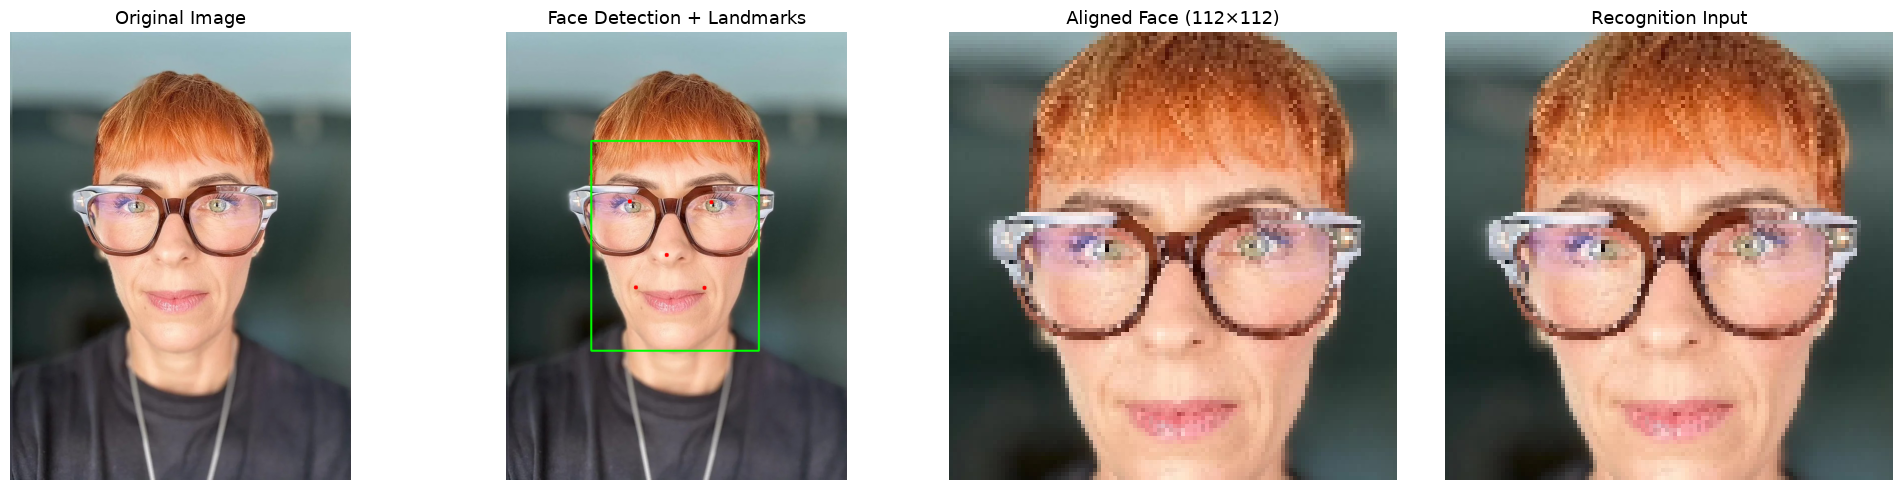


Embedding information:
Dimension : (512,)
Dtype     : float32
Norm      : 1.0
Embedding: [ 0.07840966 -0.03658825 -0.02300777  0.07894542  0.03536726]... [ 0.05309666 -0.01305409 -0.01624002 -0.042581   -0.06102401]


In [13]:
visualize_face_pipeline(sample_image_path)

# Insert into Pinecone 

In [14]:
FACE_IMAGE_DIR

WindowsPath('data/face_images')

In [15]:
index_directory(FACE_IMAGE_DIR)  # Index all images in the face_images directory

Embedded 000001.jpg  (512-dim)
Embedded 000002.jpg  (512-dim)
Embedded 000003.jpg  (512-dim)
Embedded 000004.jpg  (512-dim)
Embedded 000005.jpg  (512-dim)
Embedded 000006.jpg  (512-dim)
Embedded 000007.jpg  (512-dim)
Embedded 000008.jpg  (512-dim)
Embedded 000009.jpg  (512-dim)
Embedded 000010.jpg  (512-dim)
Embedded 000011.jpg  (512-dim)
Embedded 000012.jpg  (512-dim)
Embedded 000013.jpg  (512-dim)
Embedded 000014.jpg  (512-dim)
Embedded 000015.jpg  (512-dim)
Embedded 000016.jpg  (512-dim)
Embedded 000017.jpg  (512-dim)
Embedded 000018.jpg  (512-dim)
Embedded 000019.jpg  (512-dim)
Embedded 000020.jpg  (512-dim)
Embedded Katie+Kaars.jpg  (512-dim)
Embedded Katie_left.jpg  (512-dim)
Embedded Katie_right.jpg  (512-dim)

Upserted 23 face embedding(s) into Pinecone.


In [16]:
query_image_path1 = Path('data/query_images/000016.jpg')
query_image_path2 = Path('data/query_images/000030.jpg')
query_image_path3 = Path('data/query_images/000016-Half.jpg')
query_image_path4 = Path('data/query_images/Katie_right.jpg')
query_image_path5 = Path('data/query_images/Katie_left.jpg')

In [17]:
from src.search_face import search

In [18]:
angle1, result1 = search(query_image_path1)
angle1, result1

d:\Programming\vector-based-image-similarity-search\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


('straight',
 QueryResponse(matches=[ScoredVector(id='face::000016', score=0.998988152, values=[], metadata={'angle': 'straight', 'embedding_model': 'buffalo_l', 'image_name': '000016.jpg', 'indexed_at': '2026-08-18T17:09:03.958740+00:00', 'local_path': 'd:\\Programming\\vector-based-image-similarity-search\\data\\face_images\\000016.jpg'}), ScoredVector(id='face::000013', score=0.102504738, values=[], metadata={'angle': 'straight', 'embedding_model': 'buffalo_l', 'image_name': '000013.jpg', 'indexed_at': '2026-08-18T17:09:03.227065+00:00', 'local_path': 'd:\\Programming\\vector-based-image-similarity-search\\data\\face_images\\000013.jpg'}), ScoredVector(id='face::000019', score=0.0917720795, values=[], metadata={'angle': 'straight', 'embedding_model': 'buffalo_l', 'image_name': '000019.jpg', 'indexed_at': '2026-08-18T17:09:04.737880+00:00', 'local_path': 'd:\\Programming\\vector-based-image-similarity-search\\data\\face_images\\000019.jpg'})], namespace='', usage=Usage(read_units=1, 

In [19]:
angle2, result2 = search(query_image_path2)
angle2, result2

d:\Programming\vector-based-image-similarity-search\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


('straight',
 QueryResponse(matches=[ScoredVector(id='face::000008', score=0.124995239, values=[], metadata={'angle': 'straight', 'embedding_model': 'buffalo_l', 'image_name': '000008.jpg', 'indexed_at': '2026-08-18T17:09:01.966847+00:00', 'local_path': 'd:\\Programming\\vector-based-image-similarity-search\\data\\face_images\\000008.jpg'}), ScoredVector(id='face::Katie+Kaars', score=0.102854736, values=[], metadata={'angle': 'straight', 'embedding_model': 'buffalo_l', 'image_name': 'Katie+Kaars.jpg', 'indexed_at': '2026-08-18T17:09:05.214133+00:00', 'local_path': 'd:\\Programming\\vector-based-image-similarity-search\\data\\face_images\\Katie+Kaars.jpg'}), ScoredVector(id='face::000003', score=0.0975036621, values=[], metadata={'angle': 'straight', 'embedding_model': 'buffalo_l', 'image_name': '000003.jpg', 'indexed_at': '2026-08-18T17:09:00.724729+00:00', 'local_path': 'd:\\Programming\\vector-based-image-similarity-search\\data\\face_images\\000003.jpg'})], namespace='', usage=Usage

In [20]:
result2['matches']

[ScoredVector(id='face::000008', score=0.124995239, values=[], metadata={'angle': 'straight', 'embedding_model': 'buffalo_l', 'image_name': '000008.jpg', 'indexed_at': '2026-08-18T17:09:01.966847+00:00', 'local_path': 'd:\\Programming\\vector-based-image-similarity-search\\data\\face_images\\000008.jpg'}),
 ScoredVector(id='face::Katie+Kaars', score=0.102854736, values=[], metadata={'angle': 'straight', 'embedding_model': 'buffalo_l', 'image_name': 'Katie+Kaars.jpg', 'indexed_at': '2026-08-18T17:09:05.214133+00:00', 'local_path': 'd:\\Programming\\vector-based-image-similarity-search\\data\\face_images\\Katie+Kaars.jpg'}),
 ScoredVector(id='face::000003', score=0.0975036621, values=[], metadata={'angle': 'straight', 'embedding_model': 'buffalo_l', 'image_name': '000003.jpg', 'indexed_at': '2026-08-18T17:09:00.724729+00:00', 'local_path': 'd:\\Programming\\vector-based-image-similarity-search\\data\\face_images\\000003.jpg'})]

In [21]:
def display_query_and_best_match(query_image_path, angle, search_result):
    """Display the query image and the highest-scoring matched image side-by-side. """
    # Get highest-scoring match
    best_match = max(search_result.matches, key=lambda match: match.score)
    best_score = best_match.score
    if best_score < 0.6:
        print(f"No Match Found!")
        return
    matched_image_path = best_match.metadata["local_path"]

    # Load query image
    query_image = cv2.imread(query_image_path)
    if query_image is None:
        raise ValueError(f"Could not load query image: {query_image_path}")

    # Load matched image
    matched_image = cv2.imread(matched_image_path)
    if matched_image is None:
        raise ValueError(f"Could not load matched image: {matched_image_path}")
    
    query_image = cv2.cvtColor(query_image, cv2.COLOR_BGR2RGB)
    matched_image = cv2.cvtColor(matched_image, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Query image
    axes[0].imshow(query_image)
    axes[0].set_title("Query Image",fontsize=14)
    axes[0].axis("off")

    # Best matched image
    axes[1].imshow(matched_image)
    axes[1].set_title(
        f"Best Match\n"
        f"{best_match.metadata['image_name']}\n"
        f"Similarity Score: {best_score:.4f}\n"
        f"Angle: {best_match.metadata['angle']}",
        fontsize=14
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


    print("Best Match:")
    print("ID       :", best_match.id)
    print("Image    :", best_match.metadata["image_name"])
    print("Angle    :", best_match.metadata["angle"])
    print("Score    :", best_score)
    print("Path     :", matched_image_path)

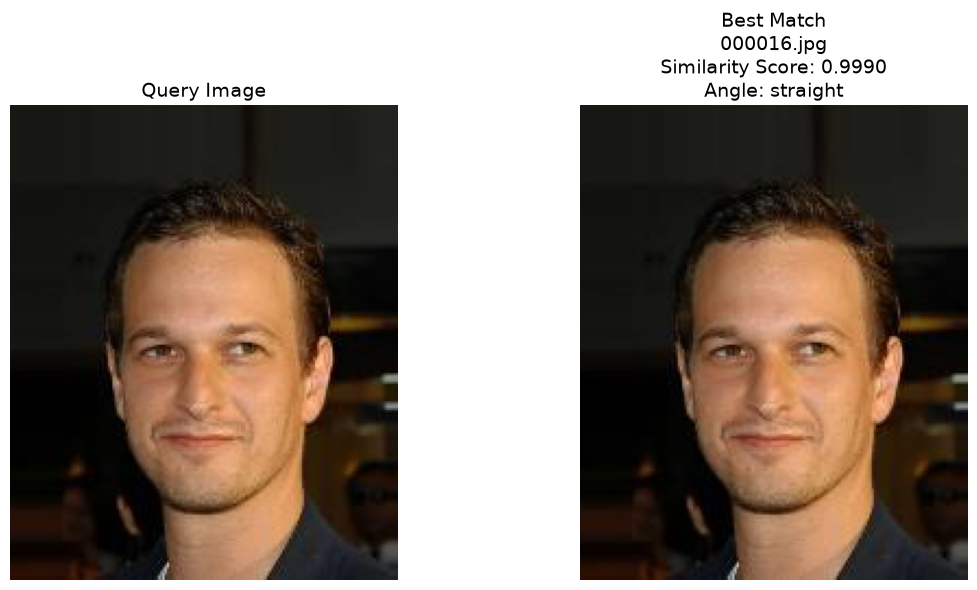

Best Match:
ID       : face::000016
Image    : 000016.jpg
Angle    : straight
Score    : 0.998988152
Path     : d:\Programming\vector-based-image-similarity-search\data\face_images\000016.jpg


In [23]:
display_query_and_best_match(query_image_path1, angle1, result1)

In [24]:
display_query_and_best_match(query_image_path2, angle2, result2)

No Match Found!


d:\Programming\vector-based-image-similarity-search\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


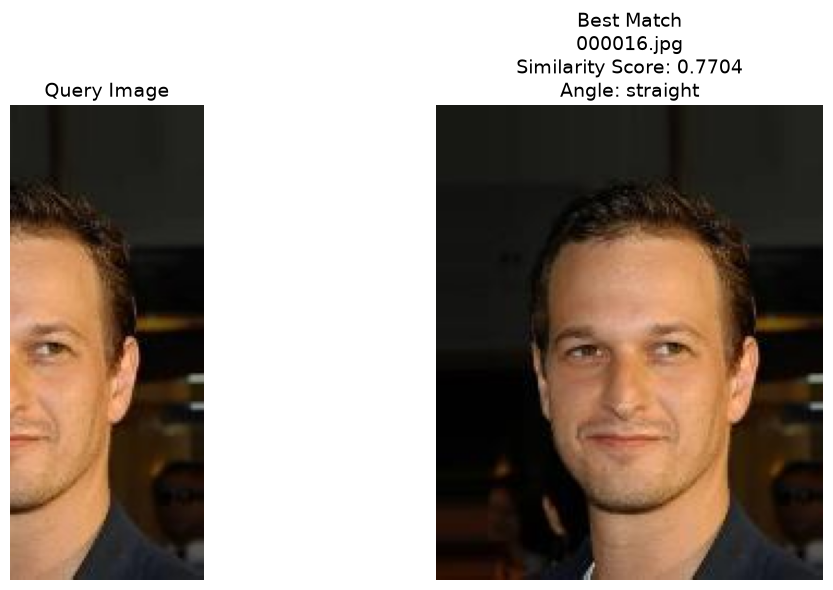

Best Match:
ID       : face::000016
Image    : 000016.jpg
Angle    : straight
Score    : 0.770445883
Path     : d:\Programming\vector-based-image-similarity-search\data\face_images\000016.jpg


In [25]:
angle3, result3 = search(query_image_path3)
display_query_and_best_match(query_image_path3, angle3, result3)

d:\Programming\vector-based-image-similarity-search\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


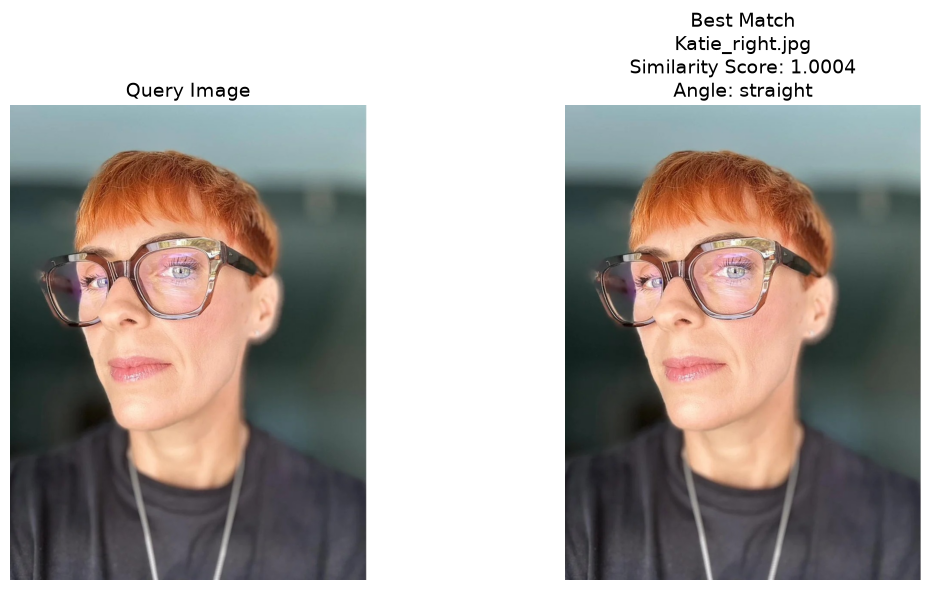

Best Match:
ID       : face::Katie_right
Image    : Katie_right.jpg
Angle    : straight
Score    : 1.00042915
Path     : d:\Programming\vector-based-image-similarity-search\data\face_images\Katie_right.jpg


In [26]:
angle4, result4 = search(query_image_path4)
display_query_and_best_match(query_image_path4, angle4, result4)

d:\Programming\vector-based-image-similarity-search\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


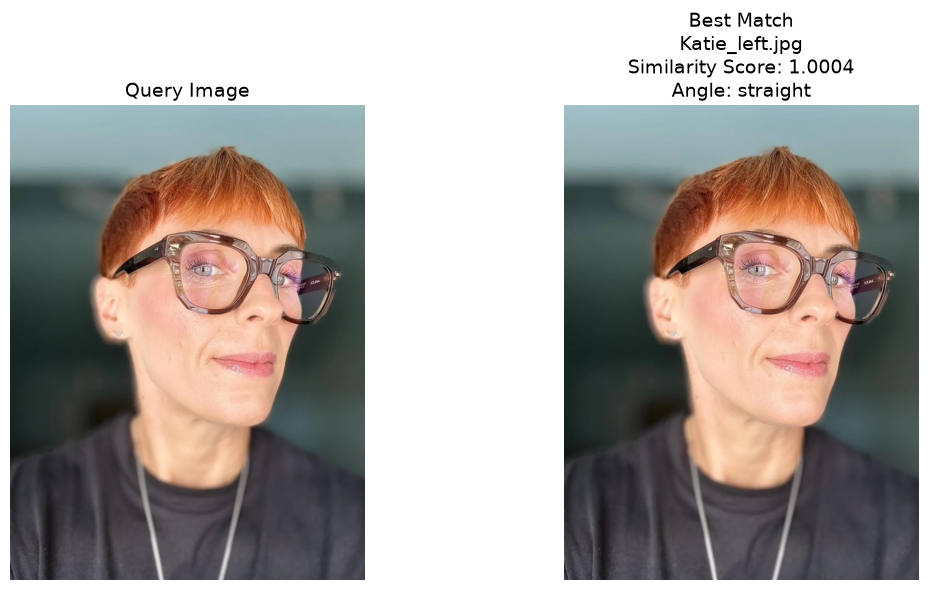

Best Match:
ID       : face::Katie_left
Image    : Katie_left.jpg
Angle    : straight
Score    : 1.00037861
Path     : d:\Programming\vector-based-image-similarity-search\data\face_images\Katie_left.jpg


In [27]:
angle5, result5 = search(query_image_path5)
display_query_and_best_match(query_image_path5, angle5, result5)